## Lieden Clustering

The purpose of this notebook is to test lieden clustering for protein data. I can presume that something similiar was done to establish cell labeling in the first place

#### Protein Load In

In [26]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

# Load files on Evan's Laptop
expr_orig = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\expression.csv", index_col=0)
expr=expr_orig.transpose()
metadata = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\metadata.csv", index_col=0)
umap = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\umap.csv", index_col=0)

#Load files on Lab computer
# expr_orig = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\expression.csv", index_col=0)
# expr=expr_orig.transpose()
# metadata = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\metadata.csv", index_col=0)
# umap = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\umap.csv", index_col=0)

# Create AnnData object
adata = sc.AnnData(X=expr.values)

# Assign metadata
adata.obs = metadata
adata.var_names = expr.columns
adata.obs_names = expr.index

# Add spatial coordinates and UMAP to .obsm
# adata.obsm["spatial"] = metadata[['x_FOV_px', 'y_FOV_px']].values  # adjust if needed
adata.obsm["spatial"] = metadata[['x_FOV_px']].assign(y_FOV_px = -metadata['y_FOV_px']).values # Note that the Y acis is inverted. This is done to standardize with RNA plots

In [29]:

############## STEP 1 PREPROSSESSING ##################
# Normalize and log1p transform the data
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Optionally, find highly variable features (HVGs)
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=30)
adata = adata[:, adata.var.highly_variable]  # subset to HVGs

# Scale the data (mean=0, std=1)
sc.pp.scale(adata, max_value=10)

############## STEP 2 PCA and neighboors ##################

# Principal Component Analysis
sc.tl.pca(adata, svd_solver='arpack')

# Compute the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=15)



C:\Users\evanj\anaconda3\Lib\site-packages\scanpy\preprocessing\_scale.py:317: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [6]:
!pip3 install leidenalg

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 2.1 MB/s eta 0:00:01
   --------------------------------- ------ 1.3/1.6 MB 2.4 MB/s eta 0:00:01
   --------------------------------- ------ 1.3/1.6 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.0 MB/s eta 0:00:00


In [14]:
############## STEP 3 Actual Clustering ##################

# Run Leiden clustering
sc.tl.leiden(adata, resolution=.3)  # Try different resolutions (0.3 - 1.0)


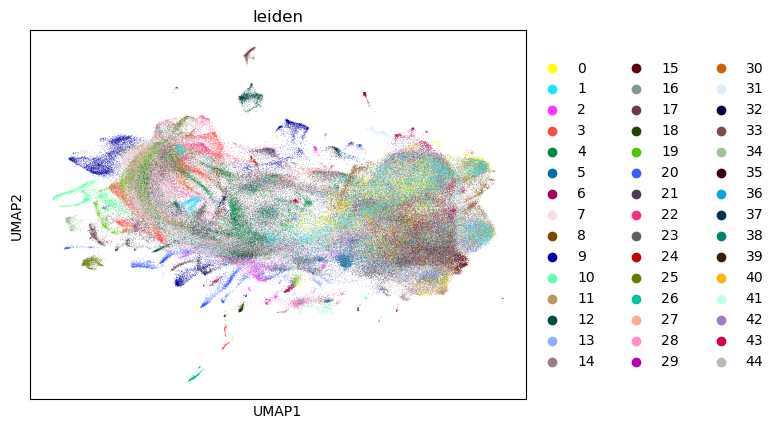

KeyError: "Spatial key 'spatial' not found in `adata.uns`."

In [15]:
############## STEP 4 Visual ##################

# Use your existing UMAP
sc.pl.umap(adata, color=['leiden'])

# Spatial plot using Squidpy
# sq.pl.spatial_scatter(adata, color="leiden", size=20, img=None)


In [10]:
# Check shape of umap DataFrame
print(umap.shape)         # Should be (n_cells, 2)
print(adata.n_obs)        # Should match number of rows in umap

# Assign UMAP only if shape matches
if umap.shape[0] == adata.n_obs and umap.shape[1] == 2:
    adata.obsm["X_umap"] = umap.values
else:
    raise ValueError("UMAP shape mismatch: cannot assign to adata.obsm['X_umap']")


(272605, 2)
272605


In [28]:
# Choose relevant proteins
marker_proteins = ['CD11b', 'CD15', 'CD16']  # Example

# Dotplot (good for many markers)
sc.pl.dotplot(adata, var_names=marker_proteins, groupby='leiden', standard_scale='var')

# Violin plot (better for a few markers)
sc.pl.violin(adata, keys=marker_proteins, groupby='leiden', rotation=90)

# Heatmap (detailed view)
sc.pl.heatmap(adata, var_names=marker_proteins, groupby='leiden', standard_scale='var')


# Must have neighbors + PCA already computed (you already did)
sc.tl.dendrogram(adata, groupby='leiden')

# Plot heatmap with dendrogram
sc.pl.heatmap(
    adata,
    var_names=marker_proteins,
    groupby='leiden',
    dendrogram=True,
    standard_scale='var'
)

ValueError: groupby has to be a valid observation. Given leiden, is not in observations: ['cell_ID', 'RNA_pca_cluster_default', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_negprobes', 'nFeature_negprobes', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.Yellow', 'Max.Yellow', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'fov', 'cell_id', 'assay_type', 'dualfiles', 'Run_name', 'Slide_name', 'tissue', 'Alpha', 'slide_ID_numeric', 'Run_Tissue_name', 'Panel', 'Mean.panCK', 'Max.panCK', 'Mean.CD3e', 'Max.CD3e', 'Mean.B2M.ATPase', 'Max.B2M.ATPase', 'Area.um2', 'x_FOV_px', 'y_FOV_px', 'x_slide_mm', 'y_slide_mm', 'area.qc', 'mean.neg', 'negprobe.qc', 'n_high_quant', 'high.express.qc', 'n_low_quant', 'low.express.qc', 'remove_flagged_cells', 'modified.celltyping.round_1', 'modified.celltyping.round_2', 'modified.celltyping.round_3', 'modified.celltyping.cell_type_number', 'modified.celltyping.final_cell_type', 'cell_type

In [30]:
display(adata.var_names)
display(expr.columns)

Index(['B7-H3', 'Beta-catenin', 'CD16', 'CD163', 'CD20', 'CD27', 'CD3', 'CD31',
       'CD34', 'CD38', 'CD39', 'CD4', 'CD40', 'CD45', 'CD8', 'CTLA4', 'EpCAM',
       'FN1', 'GZMA', 'HER2', 'HLA-DRA', 'ICOS', 'IDO1', 'IL-18', 'LAMP1',
       'SMA', 'STING', 'VIM', 'VISTA', 'iNOS'],
      dtype='object')

Index(['4-1BB', 'B7-H3', 'BCL2', 'Beta-catenin', 'CCR7', 'CD11b', 'CD11c',
       'CD123', 'CD127', 'CD138', 'CD14', 'CD15', 'CD16', 'CD163', 'CD19',
       'CD20', 'CD27', 'CD3', 'CD31', 'CD34', 'CD38', 'CD39', 'CD4', 'CD40',
       'CD45', 'CD45RA', 'CD56', 'CD68', 'CD8', 'CTLA4', 'EGFR', 'EpCAM',
       'FABP4', 'FN1', 'FOXP3', 'GITR', 'GZMA', 'GZMB', 'HER2', 'HLA-DRA',
       'ICAM1', 'ICOS', 'IDO1', 'IL-18', 'IL-1B', 'IgD', 'KI67', 'LAG3',
       'LAMP1', 'NF-kBp65', 'PD1', 'PDL1', 'PDL2', 'SMA', 'STING', 'TCF-1',
       'TIM3', 'VIM', 'VISTA', 'iNOS', 'p53', 'panRAS'],
      dtype='object')

Displaying UMAP plot with Leiden clusters...


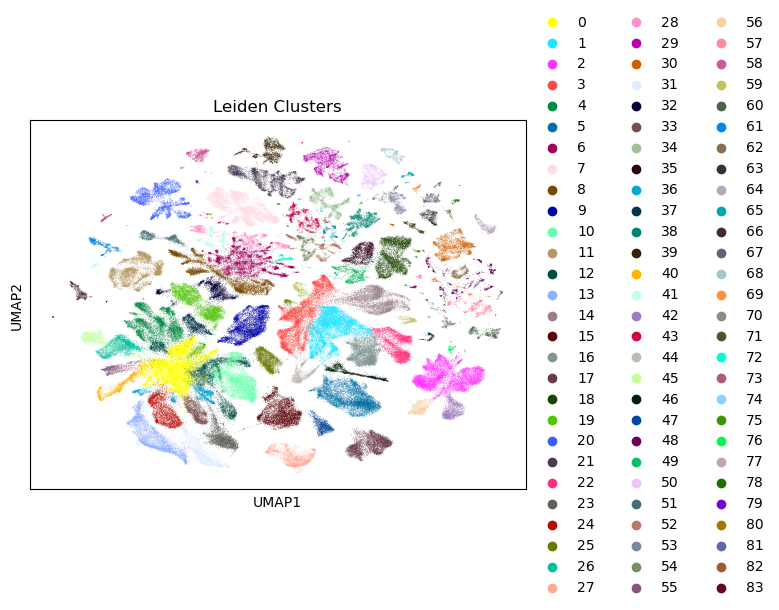

Displaying spatial plot with Leiden clusters...


C:\Users\evanj\anaconda3\Lib\site-packages\squidpy\pl\_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
C:\Users\evanj\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


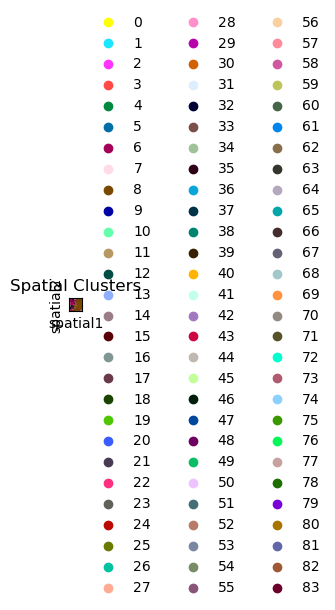

In [32]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

# Load files on Evan's Laptop
expr_orig = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\expression.csv", index_col=0)
expr = expr_orig.transpose()
metadata = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\metadata.csv", index_col=0)
# umap = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\umap.csv", index_col=0) # This is not needed if you compute a new UMAP

# Create AnnData object
adata = sc.AnnData(X=expr.values)

# Assign metadata
adata.obs = metadata
adata.var_names = expr.columns
adata.obs_names = expr.index

# Add spatial coordinates to .obsm
# Note that the Y axis is inverted. This is done to standardize with RNA plots
adata.obsm["spatial"] = metadata[['x_FOV_px']].assign(y_FOV_px=-metadata['y_FOV_px']).values

# --- Start of New Code for Clustering ---

# 1. Preprocessing and Normalization
# Normalize for total expression per cell, then log-transform the data
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# 2. Principal Component Analysis (PCA)
# Reduce the dimensionality of the data
sc.pp.pca(adata, n_comps=30)

# 3. Build Neighborhood Graph
# This is required for both clustering and UMAP
# n_neighbors controls how many neighbors are considered for each cell
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)

# 4. Leiden Clustering
# The resolution parameter controls the number of clusters (higher resolution -> more clusters)
sc.tl.leiden(adata, resolution=0.5, key_added="leiden_clusters")

# 5. UMAP for Visualization
# Compute UMAP embedding to visualize the clusters
sc.tl.umap(adata)

# --- Visualization ---

# 6. Plot the results
# Visualize the clusters on a UMAP plot
print("Displaying UMAP plot with Leiden clusters...")
sc.pl.umap(adata, color="leiden_clusters", title="Leiden Clusters")

# Visualize the clusters in their spatial context
print("Displaying spatial plot with Leiden clusters...")
sq.pl.spatial_scatter(adata, color="leiden_clusters", shape=None, title="Spatial Clusters")